# NCEI Weather Features

In [1]:
import pandas as pd
import numpy as np

raw_data = "../data/raw_files/BTV_NCEI_weather_data.csv"
output_csv = "../data/unified_csvs/ncei_weather_avg.csv"


## Load CSV

In [ ]:
df = pd.read_csv(raw_data)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)

df["DATE"] = pd.to_datetime(df["DATE"])
df = df.set_index("DATE")
df = df.loc["2012-01-01":"2024-12-31"]
df.head()

,STATION,NAME,AWND,FMTM,PGTM,PRCP,PSUN,SNOW,SNWD,TAVG,TMAX,TMIN,TSUN,WDF2,WDF5,WESD,WSF2,WSF5,WT01,WT02,WT03,WT04,WT05,WT06,WT07,WT08,WT09,WT11,WT13,WT14,WT15,WT16,WT17,WT18,WT19,WT21,WT22,WV01,WV03
DATE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2000-01-01,USW00014742,"BURLINGTON INTERNATIONAL AIRPORT, VT US",4.6,1309.0,1231.0,0.0,NaN,0.0,0.0,-0.6,5.0,-6.7,265.0,190.0,190.0,0.0,11.2,14.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
2000-01-02,USW00014742,"BURLINGTON INTERNATIONAL AIRPORT, VT US",2.6,2318.0,2205.0,4.8,NaN,0.0,0.0,3.9,10.6,-3.3,122.0,180.0,190.0,0.0,10.7,13.9,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-03,USW00014742,"BURLINGTON INTERNATIONAL AIRPORT, VT US",4.9,928.0,1037.0,2.8,NaN,18.0,25.0,5.0,12.8,-2.8,194.0,360.0,360.0,0.0,10.7,13.4,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN
2000-01-04,USW00014742,"BURLINGTON INTERNATIONAL AIRPORT, VT US",5.4,1446.0,1445.0,8.4,NaN,10.0,25.0,5.0,11.7,-2.2,0.0,230.0,230.0,0.0,13.4,17.4,1.0,NaN,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN
2000-01-05,USW00014742,"BURLINGTON INTERNATIONAL AIRPORT, VT US",5.5,209.0,208.0,0.0,NaN,0.0,0.0,-3.9,2.8,-10.6,327.0,330.0,320.0,0.0,11.6,14.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 9528 entries, 2000-01-01 to 2026-01-31
Data columns (total 39 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  9528 non-null   str    
 1   NAME     9528 non-null   str    
 2   AWND     9514 non-null   float64
 3   FMTM     4273 non-null   float64
 4   PGTM     4185 non-null   float64
 5   PRCP     9528 non-null   float64
 6   PSUN     975 non-null    float64
 7   SNOW     9520 non-null   float64
 8   SNWD     9526 non-null   float64
 9   TAVG     6702 non-null   float64
 10  TMAX     9528 non-null   float64
 11  TMIN     9528 non-null   float64
 12  TSUN     3137 non-null   float64
 13  WDF2     9514 non-null   float64
 14  WDF5     9484 non-null   float64
 15  WESD     4018 non-null   float64
 16  WSF2     9514 non-null   float64
 17  WSF5     9484 non-null   float64
 18  WT01     4028 non-null   float64
 19  WT02     481 non-null    float64
 20  WT03     517 non-null    float64
 21  WT04   

## Weather Key Descriptions:
For more info see *NCEI_weather_codes.pdf*

**NOTE**: Data was downloaded in metric form. Units are in mm for distance, Celcius for temperature, and meters per second for speed.

Basic Descriptors:
- **STATION**: Station identification code
- **NAME**: Name of the station (city/airport name)
- **DATE**: Date of the record (YYYY-MM-DD)

Precipitation:
- **PRCP** = Precipitation (mm)
- **SNOW** = Snowfall (mm)
- **SNWD** = Snow depth (mm)

Sunshine:
- **PSUN** = Daily percent of possible sunshine (percent)
- **TSUN** = Daily total sunshine (minutes)

Air Temperature:
- **TAVG** = Average temperature (Celcius)
- **TMAX** = Maximum temperature (Celcius)
- **TMIN** = Minimum temperature  (Celcius)

Water:
- **WESD** = Water equivalent of snow on the ground (mm)

Wind:
- **AWND** = Average daily wind speed (meters per second)
- **FMTM** = Time of fastest mile or 1-minute wind (hours and minutes HHMM)
- **PGTM** = Peak gust time (hours and minutes HHMM)
- **WDF2** = Direction of fastest 2-minute wind (degrees)
- **WDF5** = Direction of fastest 5-minute wind (degrees)
- **WSF2** = Fastest 2-minute wind speed (meters per second)
- **WSF5** = Fastest 5-minute wind speed (meters per second)

Other Weather Types:
- **WT01** = Fog, ice fog, or freezing fog
- **WT02** = Heavy fog or heavy freezing fog
- **WT03** = Thunder
- **WT04** = Ice pellets, sleet, snow pellets, or small hail
- **WT05** = Hail
- **WT06** = Glaze or rime
- **WT07** = Dust, volcanic ash, blowing dust, blowing sand, or blowing obstruction
- **WT08** = Smoke or haze
- **WT09** = Blowing or drifting snow
- **WT11** = High or damaging winds
- **WT13** = Mist
- **WT14** = Drizzle
- **WT15** = Freezing drizzle
- **WT16** = Rain
- **WT17** = Freezing rain
- **WT18** = Snow, snow pellets, snow grains, or ice crystals
- **WT19** = Unknown source of precipitation
- **WT21** = Ground fog
- **WT22** = Ice fog or freezing fog

Weather in the Vicinity:
- **WV01** = Fog, ice fog, or freezing fog
- **WV03** = Thunder

In [5]:
descriptions = {
"STATION" : "Station identification code",
"NAME" : "Name of the station (city/airport name)",
"PRCP" : "Precipitation (mm)",
"SNOW" : "Snowfall (mm)",
"SNWD" : "Snow depth (mm)",
"PSUN" : "Daily percent of possible sunshine (percent)",
"TSUN" : "Daily total sunshine (minutes)",
"TAVG" : "Average temperature (Celcius)",
"TMAX" : "Maximum temperature (Celcius)",
"TMIN" : "Minimum temperature  (Celcius)",
"WESD" : "Water equivalent of snow on the ground (mm)",
"AWND" : "Average daily wind speed (meters per second)",
"FMTM" : "Time of fastest mile or 1-minute wind (hours and minutes HHMM)",
"PGTM" : "Peak gust time (hours and minutes HHMM)",
"WDF2" : "Direction of fastest 2-minute wind (degrees)",
"WDF5" : "Direction of fastest 5-minute wind (degrees)",
"WSF2" : "Fastest 2-minute wind speed (meters per second)",
"WSF5" : "Fastest 5-minute wind speed (meters per second)",
"WT01" : "Fog, ice fog, or freezing fog",
"WT02" : "Heavy fog or heavy freezing fog",
"WT03" : "Thunder",
"WT04" : "Ice pellets, sleet, snow pellets, or small hail",
"WT05" : "Hail",
"WT06" : "Glaze or rime",
"WT07" : "Dust, volcanic ash, blowing dust, blowing sand, or blowing obstruction",
"WT08" : "Smoke or haze",
"WT09" : "Blowing or drifting snow",
"WT11" : "High or damaging winds",
"WT13" : "Mist",
"WT14" : "Drizzle",
"WT15" : "Freezing drizzle",
"WT16" : "Rain",
"WT17" : "Freezing rain",
"WT18" : "Snow, snow pellets, snow grains, or ice crystals",
"WT19" : "Unknown source of precipitation",
"WT21" : "Ground fog",
"WT22" : "Ice fog or freezing fog",
"WV01" : "Fog, ice fog, or freezing fog",
"WV03" : "Thunder"
}

categories = {
"STATION" : "Metadata",
"NAME" : "Metadata",
"PRCP" : "Precipitation",
"SNOW" : "Precipitation",
"SNWD" : "Precipitation",
"PSUN" : "Sunshine",
"TSUN" : "Sunshine",
"TAVG" : "Air Temperature",
"TMAX" : "Air Temperature",
"TMIN" : "Air Temperature",
"WESD" : "Water",
"AWND" : "Wind",
"FMTM" : "Wind",
"PGTM" : "Wind",
"WDF2" : "Wind",
"WDF5" : "Wind",
"WSF2" : "Wind",
"WSF5" : "Wind",
"WT01" : "Weather",
"WT02" : "Weather",
"WT03" : "Weather",
"WT04" : "Weather",
"WT05" : "Weather",
"WT06" : "Weather",
"WT07" : "Weather",
"WT08" : "Weather",
"WT09" : "Weather",
"WT11" : "Weather",
"WT13" : "Weather",
"WT14" : "Weather",
"WT15" : "Weather",
"WT16" : "Weather",
"WT17" : "Weather",
"WT18" : "Weather",
"WT19" : "Weather",
"WT21" : "Weather",
"WT22" : "Weather",
"WV01" : "Weather in Vicinity",
"WV03" : "Weather in Vicinity"
}

## Sort Columns by Non-Null Values

In [6]:
df_numeric = df.select_dtypes(include="number")

coverage = pd.DataFrame({
    "non_null_count": df_numeric.notna().sum(),
    "non_null_percentage": df_numeric.notna().mean()
}).sort_values("non_null_percentage", ascending=False)

coverage["category"] = categories
coverage["description"] = descriptions


coverage

,non_null_count,non_null_percentage,category,description
PRCP,9528,1.000000,Precipitation,Precipitation (mm)
TMIN,9528,1.000000,Air Temperature,Minimum temperature (Celcius)
TMAX,9528,1.000000,Air Temperature,Maximum temperature (Celcius)
SNWD,9526,0.999790,Precipitation,Snow depth (mm)
SNOW,9520,0.999160,Precipitation,Snowfall (mm)
WDF2,9514,0.998531,Wind,Direction of fastest 2-minute wind (degrees)
WSF2,9514,0.998531,Wind,Fastest 2-minute wind speed (meters per second)
AWND,9514,0.998531,Wind,Average daily wind speed (meters per second)
WSF5,9484,0.995382,Wind,Fastest 5-minute wind speed (meters per second)
WDF5,9484,0.995382,Wind,Direction of fastest 5-minute wind (degrees)


## Drop Features Below Threshold

We only want to look at features with data coverage above a certain threshold (defined arbitrarily to be 80%)

In [19]:
# Minimum data coverage to be a usable feature
THRESHOLD = 0.8

usable_features = coverage.loc[coverage["non_null_percentage"] >= THRESHOLD].index.tolist()

df_numeric = df_numeric[usable_features]
df_numeric.head()

,PRCP,TMIN,TMAX,AWND,WDF2,WSF2,SNWD,SNOW,WSF5,WDF5,TAVG
DATE,,,,,,,,,,,
2012-01-01,0.5,-1.1,7.2,3.4,180.0,10.3,0.0,0.0,14.3,190.0,NaN
2012-01-02,2.5,-6.1,6.7,4.7,330.0,10.3,0.0,5.0,13.0,340.0,NaN
2012-01-03,0.0,-15.6,-6.1,5.4,330.0,8.9,0.0,5.0,11.2,330.0,NaN
2012-01-04,0.0,-17.2,-6.1,4.3,190.0,8.9,0.0,0.0,11.6,180.0,NaN
2012-01-05,1.3,-11.7,-2.8,3.6,190.0,8.0,51.0,43.0,11.6,200.0,NaN


## Data Coverage Visualization

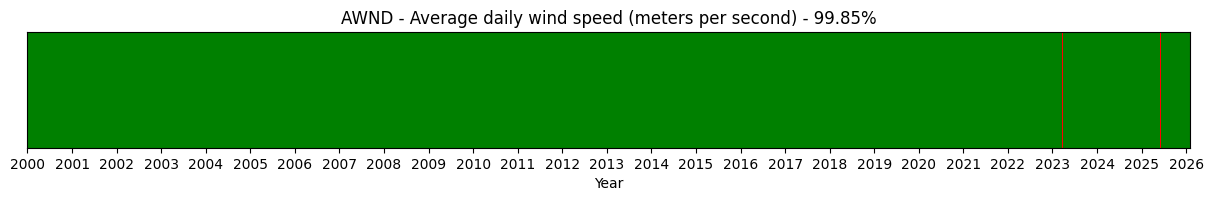

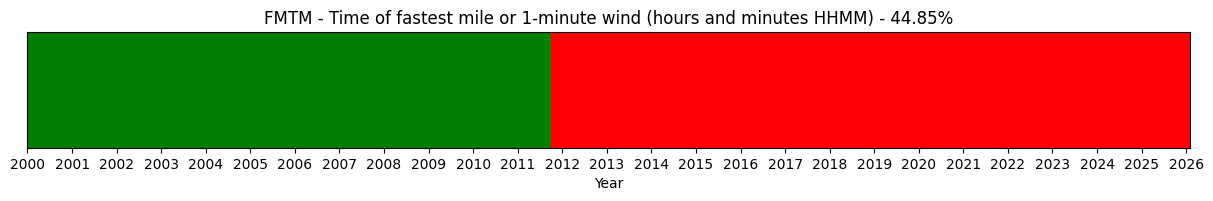

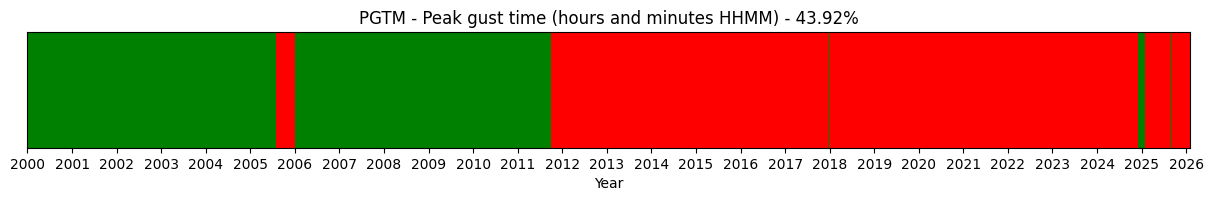

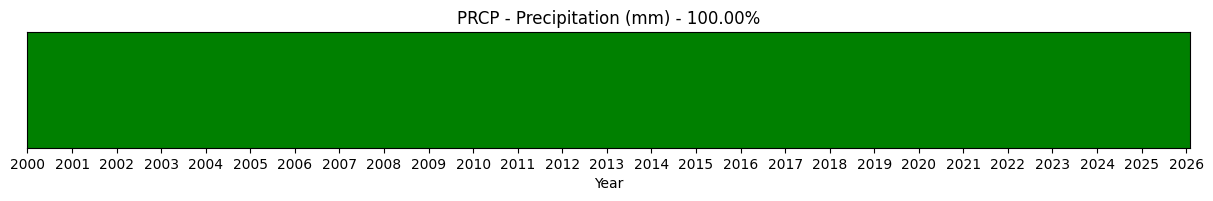

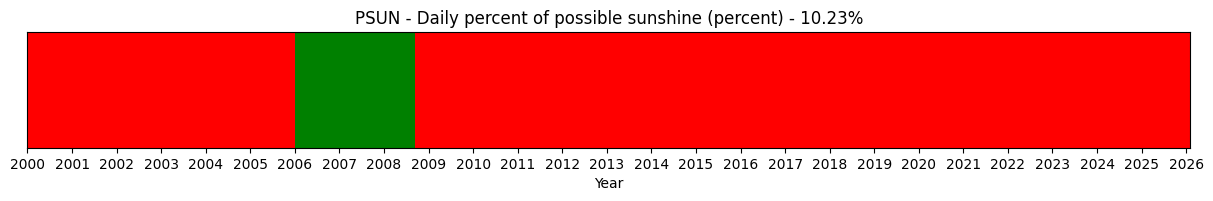

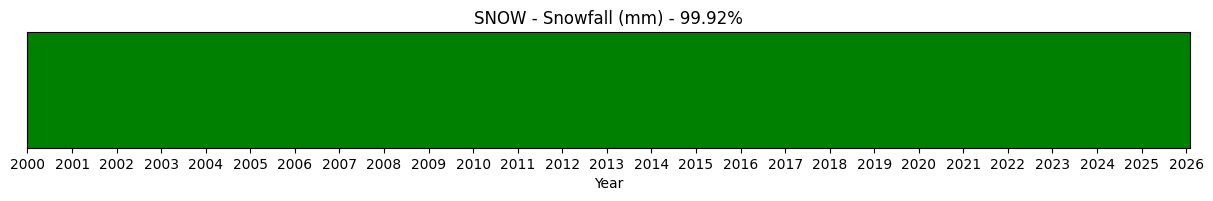

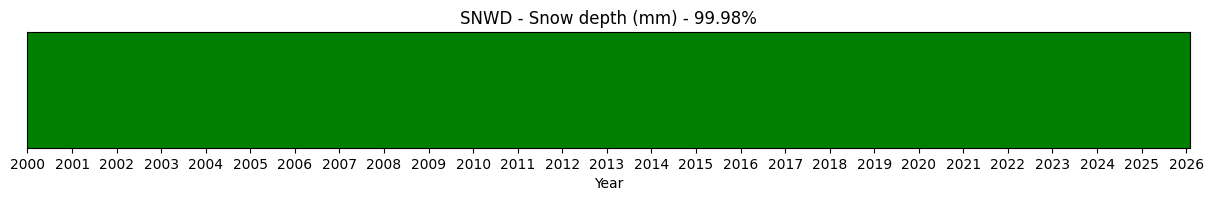

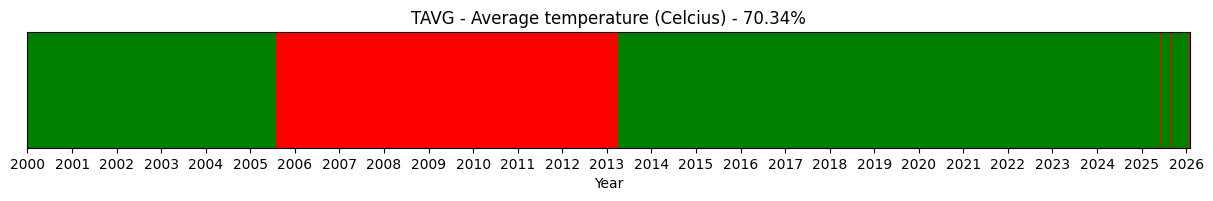

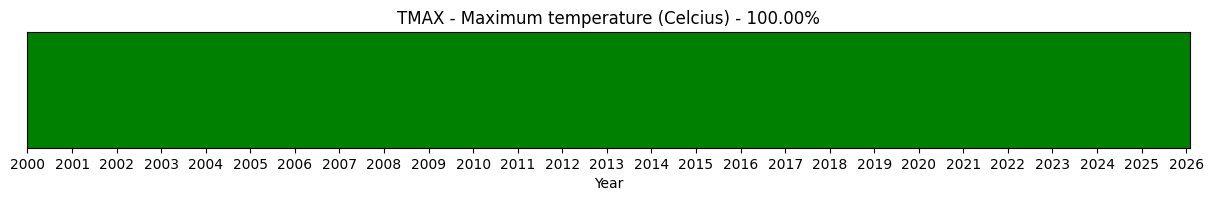

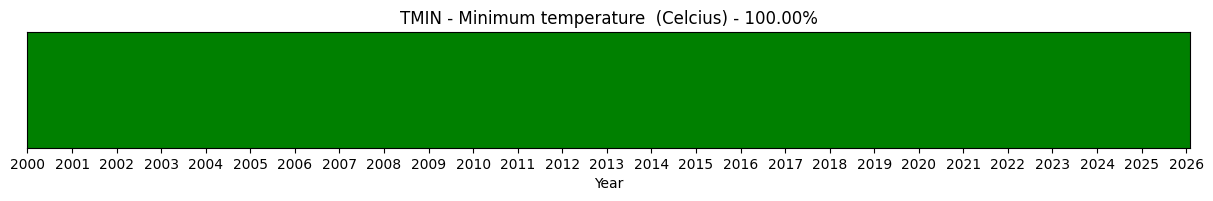

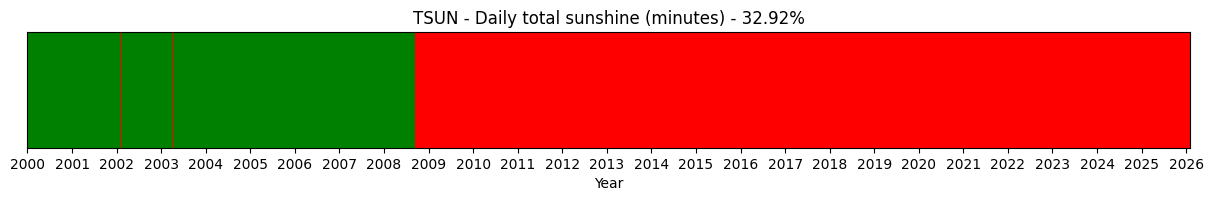

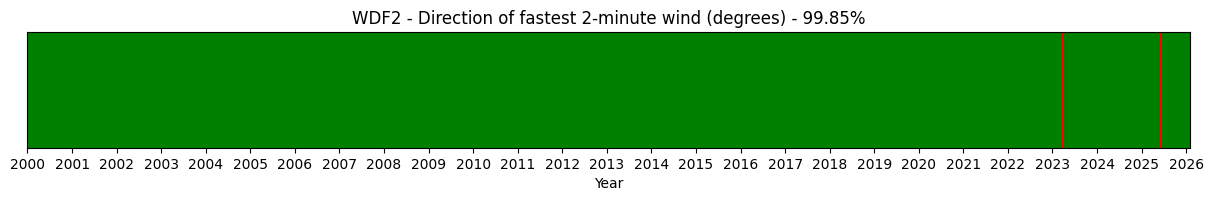

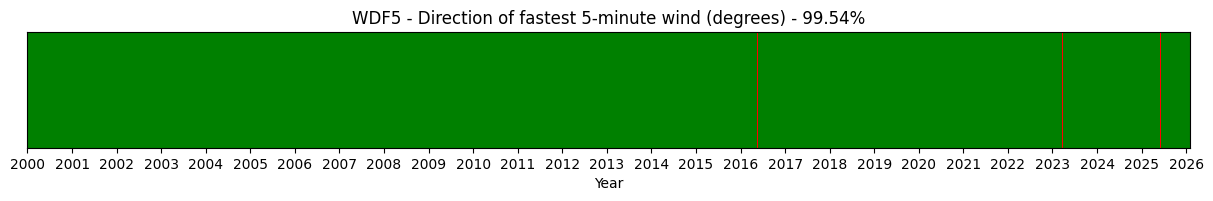

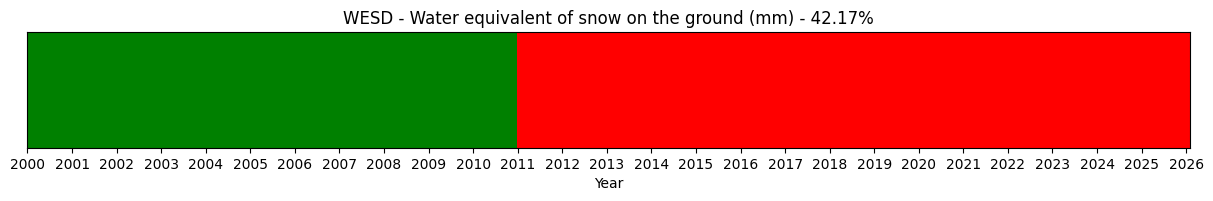

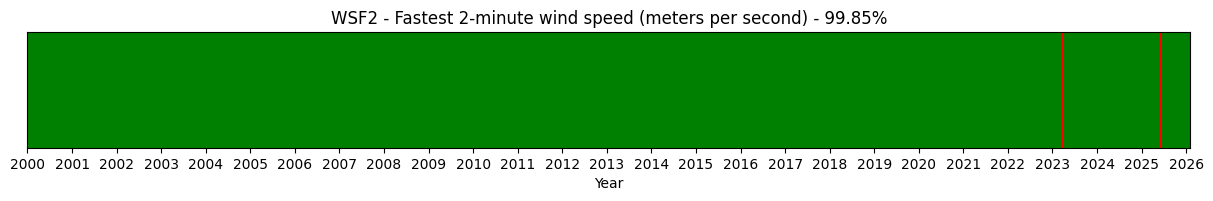

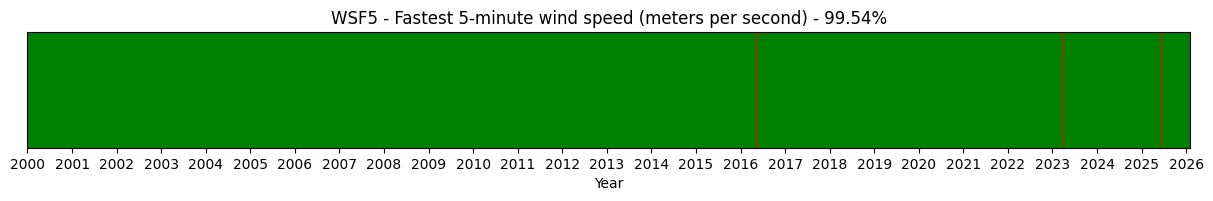

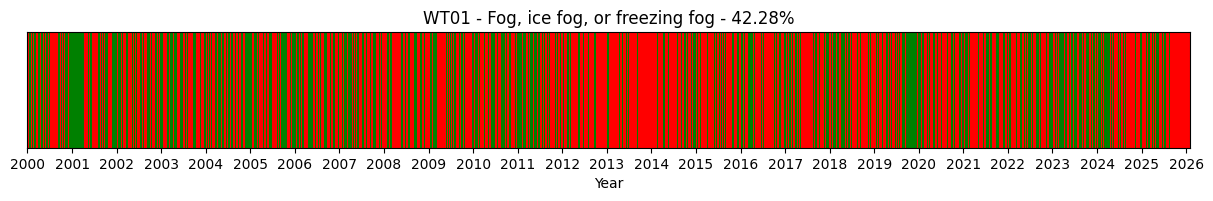

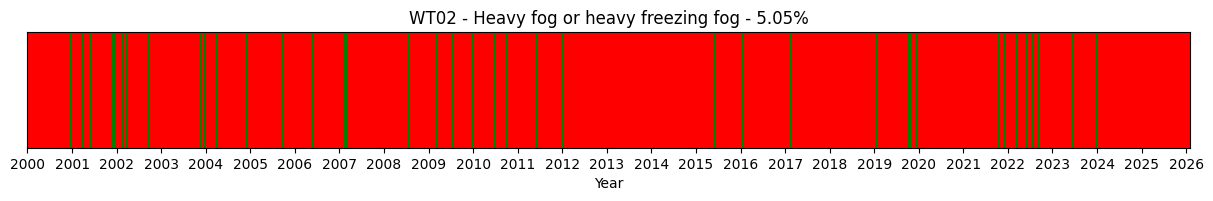

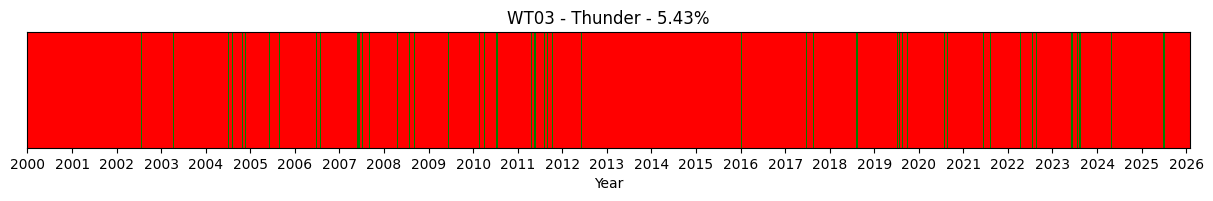

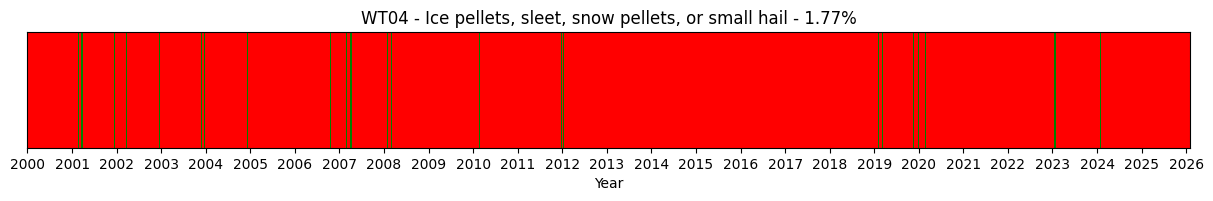

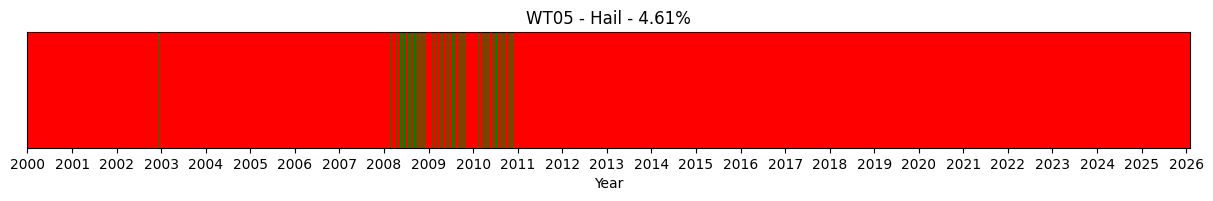

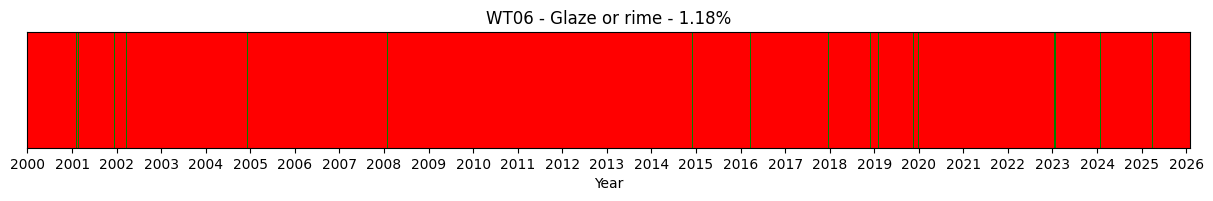

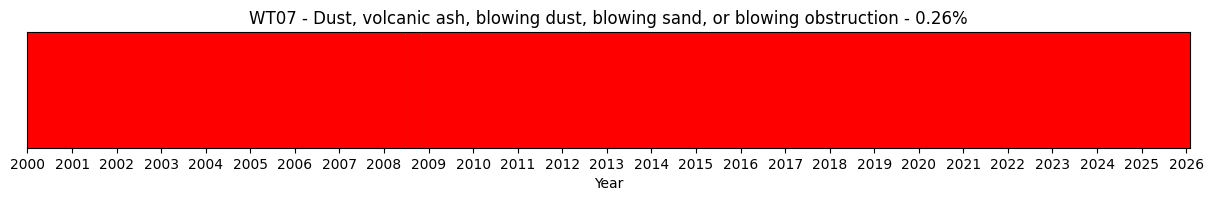

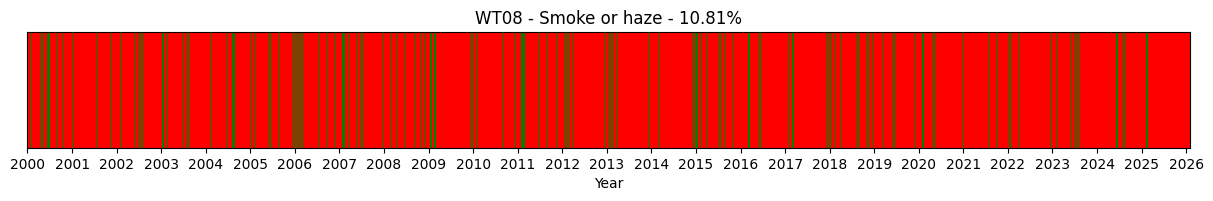

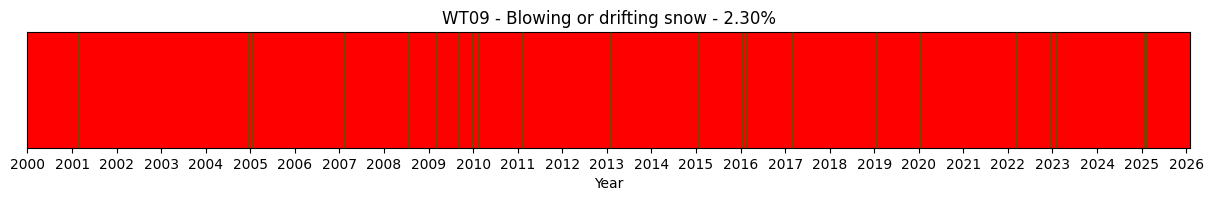

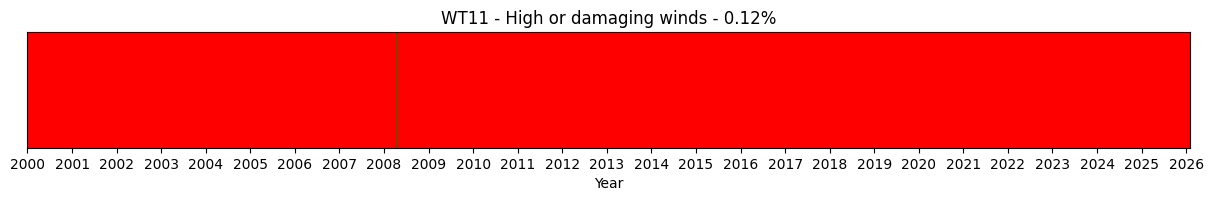

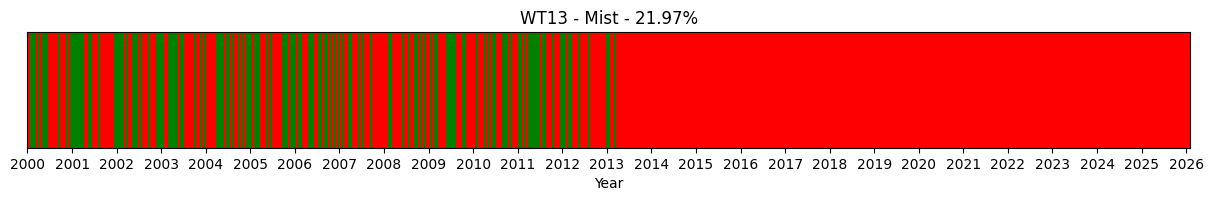

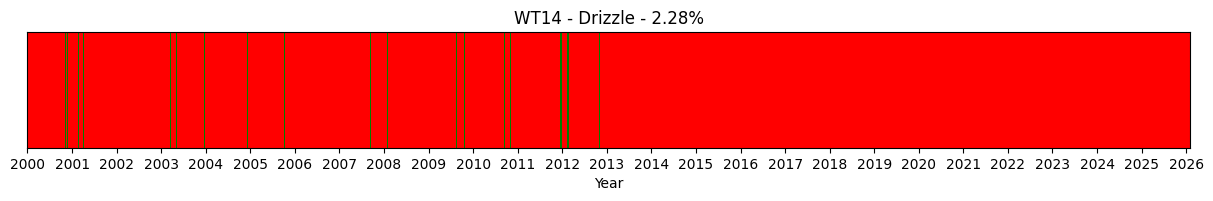

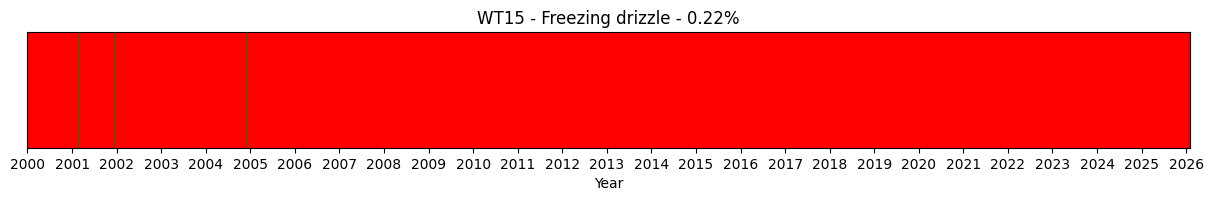

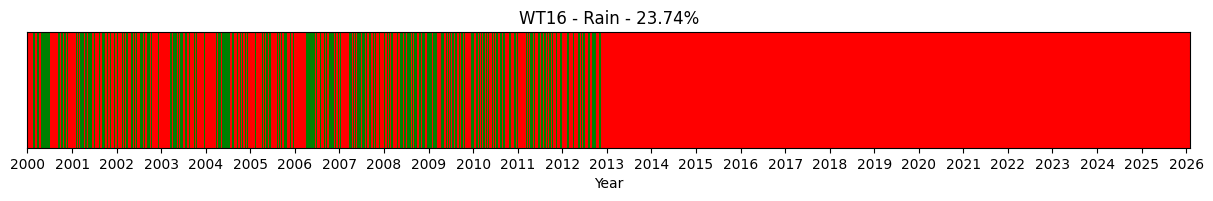

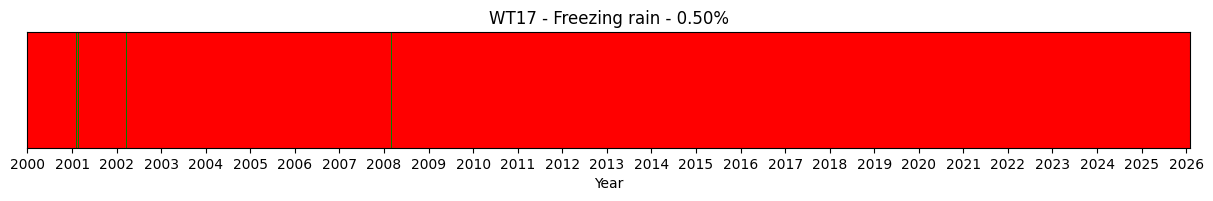

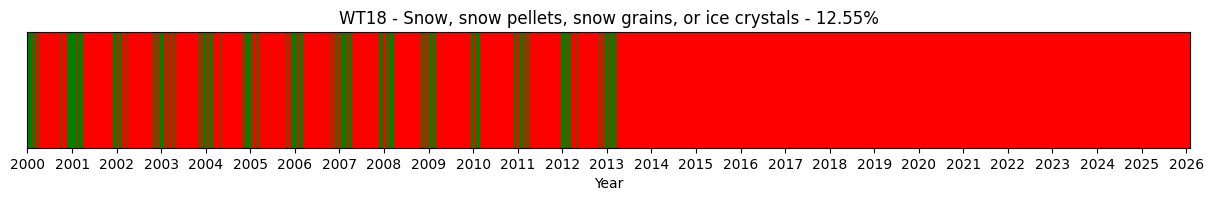

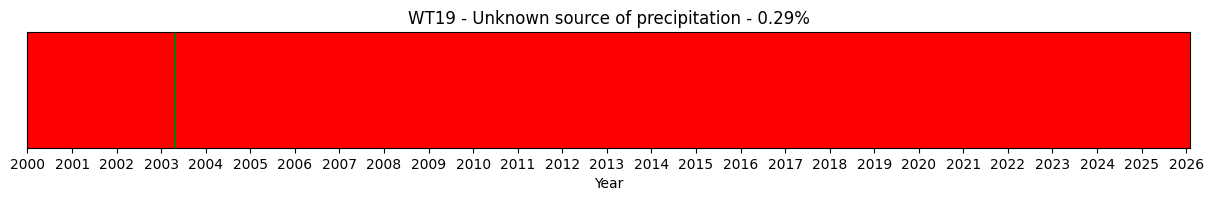

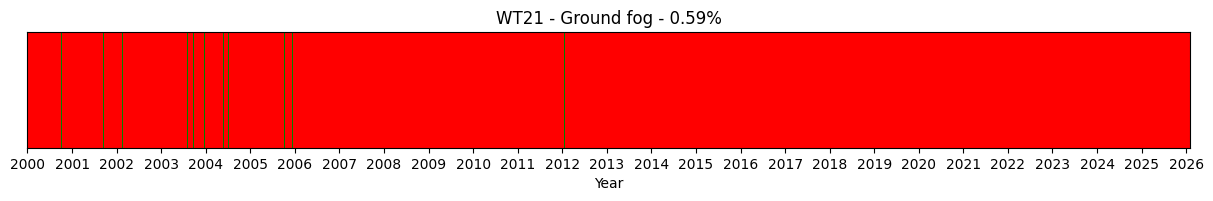

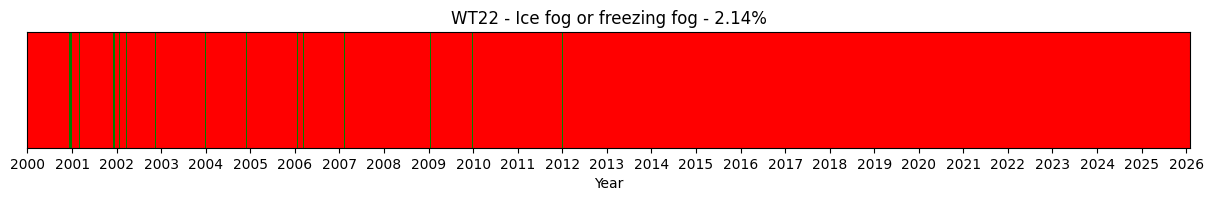

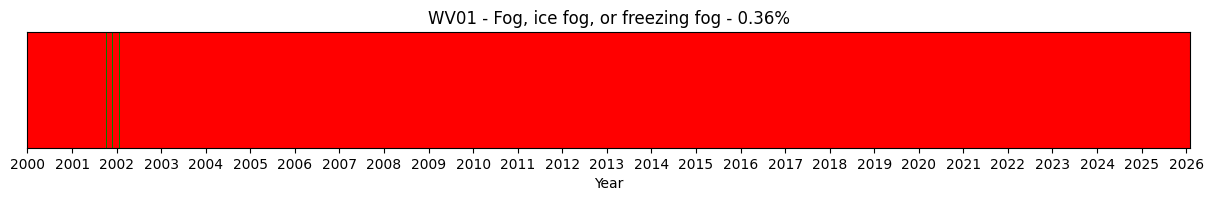

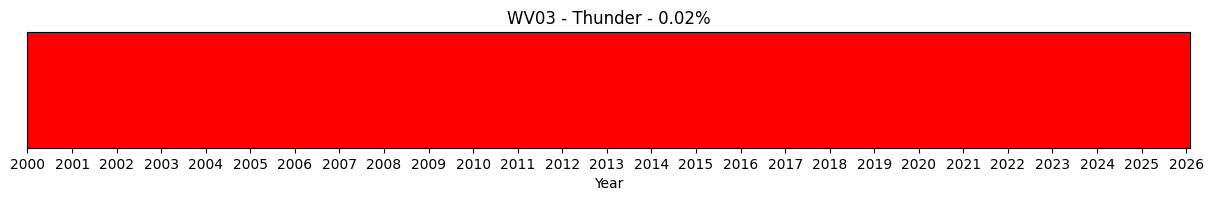

In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

data = df_numeric

# Green = present data
# Red = missing data
cmap = ListedColormap(["green", "red"])

# To plot years along x axis
years = data.index.year
unique_years = np.unique(years)
year_positions = [
    np.where(years == y)[0][0] for y in unique_years
]

for col in data.columns:
    plt.figure(figsize=(15, 1.5))
    
    missing = data[col].isna().astype(int)
    
    plt.imshow([missing], aspect="auto", cmap=cmap, interpolation="none")
    
    plt.yticks([])
    plt.title(f"{col} - {descriptions[col]} - {coverage["non_null_percentage"][col] * 100:.2f}%")
    plt.xticks(year_positions, unique_years)
    plt.xlabel("Year")
    
    plt.show()

## Trailing 7-day Average Calculation

For now, we just compute the mean of the previous 7 days (not including the day itself) and ignore null values. We will have to specify how we want to handle null values and gaps in the dataset.

In [40]:
weekly_avg = df_numeric.shift(1).rolling(window=7, min_periods=1).mean()
weekly_avg.head()

,PRCP,TMIN,TMAX,AWND,WDF2,WSF2,SNWD,SNOW,WSF5,WDF5,TAVG
DATE,,,,,,,,,,,
2012-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-02,0.50,-1.1,7.200,3.40,180.0,10.300000,0.0,0.000000,14.300000,190.000000,NaN
2012-01-03,1.50,-3.6,6.950,4.05,255.0,10.300000,0.0,2.500000,13.650000,265.000000,NaN
2012-01-04,1.00,-7.6,2.600,4.50,280.0,9.833333,0.0,3.333333,12.833333,286.666667,NaN
2012-01-05,0.75,-10.0,0.425,4.45,257.5,9.600000,0.0,2.500000,12.525000,260.000000,NaN


## Export Averages to CSV

In [41]:
weekly_avg.reset_index().to_csv(output_csv, index=False)